# Actividad para minimizar el impacto del sobre-ajuste.

## Etapa 1: Definición de los datos.

Antes de comenzar definimos la base de datos de interés. Usaremos la base de datos IMBD que consiste en reseñas hechas a 25000 películas. La tarea que configura esta base de datos consiste en predecir si el comentario es positivo o negativo. ([Ver enlace](https://keras.io/api/datasets/imdb/))

Se cargan las librerías necesarias

In [1]:
from keras.datasets import imdb
import numpy as np
from keras import models
from keras import layers
from keras import regularizers
import matplotlib.pyplot as plt

Se carga la base de datos

In [2]:
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=10000)

d:\OneDrive - Grupo EPM\8. UNIVERSIDAD JAVERIANA\Deep Learning\Caps\Actividades\.venv\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Se definen funciones para la visualización de la función de costo

In [3]:
def evaluate(model, history):
    # Se evalúa el accuracy del modelo tanto en el conjunto de entrenamiento como
    # en el de prueba.
    _, train_accuracy = model.evaluate(x_train, y_train)
    _, test_accuracy = model.evaluate(x_test, y_test)

    print(f"Trainining accuracy: {train_accuracy:.2f}")
    print(f"Testing accuracy: {test_accuracy:.2f}")

    # Se grafica la función de costo para los conjuntos de entrenamiento y
    # prueba.
    plt.figure(figsize=(4, 3), dpi=160)

    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="test")
    plt.legend()
    plt.show()

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.
    return results

In [4]:
# Procesamiento de los datos.
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

In [5]:
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

## Etapa 2: Visualización de los datos

IMDB **no son imágenes**: cada reseña es una **lista de enteros** (índices de palabras dentro de las `num_words` más frecuentes). Después de `vectorize_sequences`, cada fila `x_train[i]` tiene forma `(10000,)`: vectores tipo *bag-of-words*, no rejillas de píxeles. Por eso no se usa `imshow(x_train[i])`; en su lugar mostramos resúmenes, histogramas de longitud y un fragmento del vector grande como imagen opcional para ver **dónde hay unos**.

Formas (vectorizado): (25000, 10000) (25000, 10000)
Palabras/distintos valores por muestra tras vectorización: primera fila tiene 120 palabras únicas entre las 10000 más frecuentes
Longitud de reseñas (lista original, train): min=11, max=2494, media=238.7
Etiquetas (train): negativas=12500, positivas=12500


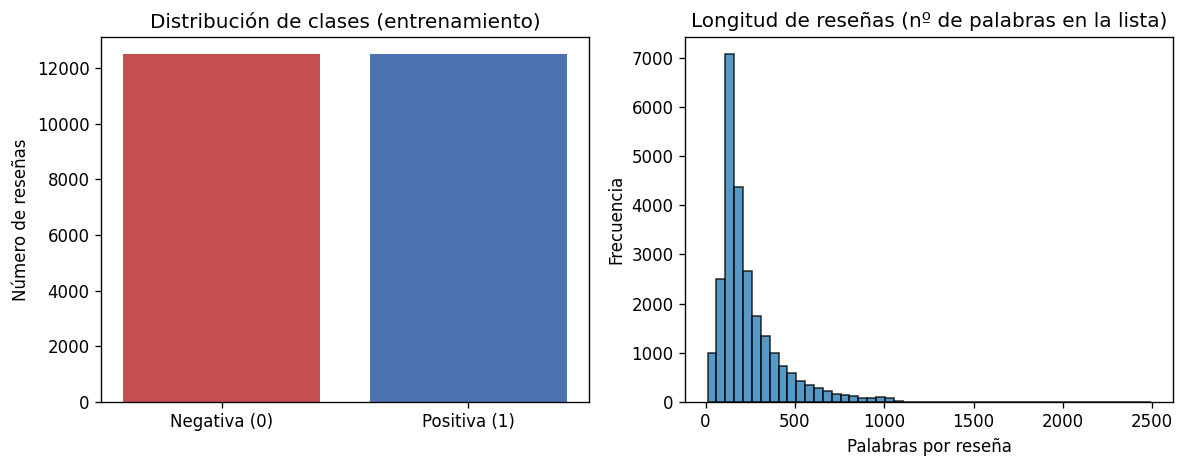

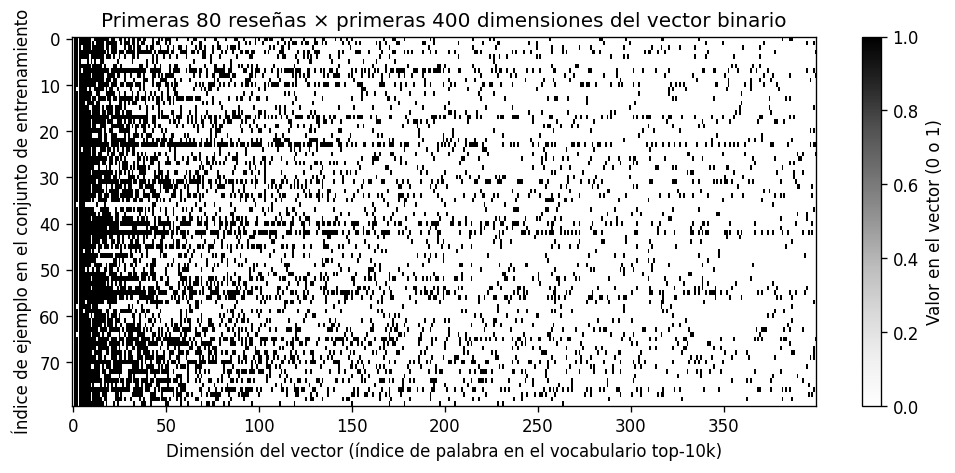

In [6]:
train_lens = np.array([len(s) for s in train_data])

print("Formas (vectorizado):", x_train.shape, x_test.shape)
print(f"Palabras/distintos valores por muestra tras vectorización: primera fila tiene {int(x_train[0].sum())} palabras únicas entre las 10000 más frecuentes")
print(
    "Longitud de reseñas (lista original, train): "
    f"min={train_lens.min()}, max={train_lens.max()}, media={train_lens.mean():.1f}"
)
print(
    "Etiquetas (train): "
    f"negativas={np.sum(train_labels == 0)}, positivas={np.sum(train_labels == 1)}"
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=120)
axes[0].bar(
    ["Negativa (0)", "Positiva (1)"],
    [np.sum(train_labels == 0), np.sum(train_labels == 1)],
    color=["#c44e52", "#4c72b0"],
)
axes[0].set_title("Distribución de clases (entrenamiento)")
axes[0].set_ylabel("Número de reseñas")

axes[1].hist(train_lens, bins=50, edgecolor="black", alpha=0.75)
axes[1].set_title("Longitud de reseñas (nº de palabras en la lista)")
axes[1].set_xlabel("Palabras por reseña")
axes[1].set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

subset = x_train[:80, :400]
plt.figure(figsize=(10, 4), dpi=120)
plt.imshow(subset, cmap="Greys", aspect="auto", interpolation="nearest")
plt.colorbar(label="Valor en el vector (0 o 1)")
plt.title("Primeras 80 reseñas × primeras 400 dimensiones del vector binario")
plt.xlabel("Dimensión del vector (índice de palabra en el vocabulario top-10k)")
plt.ylabel("Índice de ejemplo en el conjunto de entrenamiento")
plt.show()

In [7]:
word_index = imdb.get_word_index()
reverse_word_index = {v: k for k, v in word_index.items()}


def decode_review(encoded):
    return " ".join(reverse_word_index.get(i - 3, "?") for i in encoded)


for i in range(3):
    text = decode_review(train_data[i])
    short = text[:800] + ("…" if len(text) > 800 else "")
    print(f"\n--- Ejemplo {i} | etiqueta: {train_labels[i]} ({'positiva' if train_labels[i] else 'negativa'}) ---")
    print(short)


--- Ejemplo 0 | etiqueta: 1 (positiva) ---
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out …

--- Ejemplo 1 | etiqueta: 0 (negativa) ---
? big hair big boobs bad music and a giant safety pin these are the words to best describe this terrible movie

In [8]:
# Se definen los conjuntos de entrenamiento y prueba
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [9]:
# Se define la red neuronal.

model = models.Sequential([
  layers.Dense(16, activation='relu', input_shape=(10000,)),
  layers.Dense(16, activation='relu'),
  layers.Dense(1, activation='sigmoid')
  ])

d:\OneDrive - Grupo EPM\8. UNIVERSIDAD JAVERIANA\Deep Learning\Caps\Actividades\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [11]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=50,
                    batch_size=512,
                    validation_data=(x_val, y_val))


Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.7803 - loss: 0.5235 - val_accuracy: 0.8658 - val_loss: 0.3908
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8962 - loss: 0.3145 - val_accuracy: 0.8535 - val_loss: 0.3560
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9188 - loss: 0.2409 - val_accuracy: 0.8818 - val_loss: 0.2981
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9339 - loss: 0.1947 - val_accuracy: 0.8834 - val_loss: 0.2897
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9443 - loss: 0.1663 - val_accuracy: 0.8857 - val_loss: 0.2902
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9550 - loss: 0.1381 - val_accuracy: 0.8836 - val_loss: 0.3031
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9613 - loss: 0.1229 - val_accuracy: 0.8858 - val_loss: 0.2949
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9700 - loss: 0.1018 - val_accuracy: 0.8847 - val_loss

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 914us/step - accuracy: 0.9456 - loss: 0.4478
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 862us/step - accuracy: 0.8538 - loss: 1.1961
Trainining accuracy: 0.95
Testing accuracy: 0.85


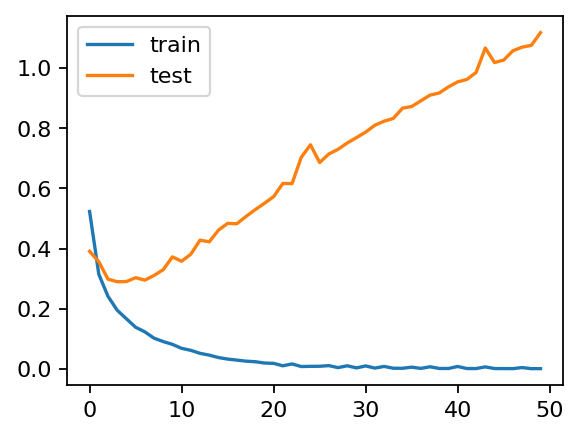

In [12]:
evaluate(model, history)